In [1]:
import csv
import json
from datetime import datetime, date

LIMITE_SUSPEITO = 10000.00
CAMINHO_CSV = "transacoes.csv"
CAMINHO_JSON = "relatorio.json"

In [2]:
def ler_transacoes(caminho_arquivo):
    transacoes = []

    try:
        with open(caminho_arquivo, "r", encoding="utf-8") as arquivo:
            leitor = csv.DictReader(arquivo)

            for linha in leitor:
                transacoes.append(linha)

    except FileNotFoundError:
        print("Erro: arquivo CSV não encontrado.")
        return []

    return transacoes

In [3]:
def validar_transacao(linha):

    id_texto = linha.get("id", "").strip()

    if not id_texto.isdigit():
        return None

    id_transacao = int(id_texto)

    cliente_id = linha.get("cliente_id", "").strip()

    if cliente_id == "":
        return None

    data_texto = linha.get("data", "").strip()

    try:
        data_transacao = datetime.strptime(data_texto, "%Y-%m-%d")
    except ValueError:
        return None

    tipo = linha.get("tipo", "").strip().lower()

    if tipo not in ["credito", "debito"]:
        return None

    valor_texto = linha.get("valor", "").strip()

    try:
        valor = float(valor_texto)
    except ValueError:
        return None

    if valor <= 0:
        return None

    descricao = linha.get("descricao", "").strip()
    categoria = linha.get("categoria", "").strip()

    transacao_limpa = {
        "id": id_transacao,
        "data": data_transacao,
        "data_texto": data_transacao.strftime("%Y-%m-%d"),
        "mes": data_transacao.strftime("%Y-%m"),
        "cliente_id": cliente_id,
        "tipo": tipo,
        "valor": valor,
        "descricao": descricao,
        "categoria": categoria,
        "suspeita": valor > LIMITE_SUSPEITO
    }

    return transacao_limpa

In [4]:
transacoes_brutas = ler_transacoes(CAMINHO_CSV)

transacoes_validas = []
transacoes_invalidas = []

for linha in transacoes_brutas:
    transacao = validar_transacao(linha)

    if transacao is None:
        transacoes_invalidas.append(linha)
    else:
        transacoes_validas.append(transacao)

print("Total de linhas lidas:", len(transacoes_brutas))
print("Linhas válidas:", len(transacoes_validas))
print("Linhas inválidas:", len(transacoes_invalidas))

Total de linhas lidas: 200
Linhas válidas: 185
Linhas inválidas: 15


In [5]:
def gerar_relatorio(transacoes):

    resumo_mensal = {}

    for transacao in transacoes:
        mes = transacao["mes"]
        valor = transacao["valor"]
        tipo = transacao["tipo"]

        if mes not in resumo_mensal:
            resumo_mensal[mes] = {
                "quantidade": 0,
                "total_credito": 0.0,
                "total_debito": 0.0,
                "saldo": 0.0,
                "media": 0.0,
                "maior_valor": valor,
                "menor_valor": valor,
                "valores": []
            }

        resumo_mensal[mes]["quantidade"] += 1
        resumo_mensal[mes]["valores"].append(valor)

        if tipo == "credito":
            resumo_mensal[mes]["total_credito"] += valor
        elif tipo == "debito":
            resumo_mensal[mes]["total_debito"] += valor

        if valor > resumo_mensal[mes]["maior_valor"]:
            resumo_mensal[mes]["maior_valor"] = valor

        if valor < resumo_mensal[mes]["menor_valor"]:
            resumo_mensal[mes]["menor_valor"] = valor

    for mes, dados in resumo_mensal.items():
        dados["saldo"] = dados["total_credito"] - dados["total_debito"]
        dados["media"] = sum(dados["valores"]) / dados["quantidade"]

        del dados["valores"]

    return resumo_mensal

In [6]:
resumo_mensal = gerar_relatorio(transacoes_validas)

print("Meses encontrados:")
print(resumo_mensal.keys())

print("\nResumo de um mês:")
print(resumo_mensal["2026-01"])

Meses encontrados:
dict_keys(['2026-06', '2026-02', '2026-05', '2026-03', '2026-04', '2026-01'])

Resumo de um mês:
{'quantidade': 33, 'total_credito': 78195.29, 'total_debito': 20142.780000000002, 'saldo': 58052.509999999995, 'media': 2979.941515151515, 'maior_valor': 12286.58, 'menor_valor': 129.34}


In [7]:
def formatar_moeda(valor):
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

In [8]:
def exibir_relatorio(resumo_mensal, transacoes_validas, transacoes_invalidas, periodo):

    print("===== RELATÓRIO FINANCEIRO CLEARBANK =====")
    print()
    print(f"Período analisado: {periodo['data_mais_antiga']} até {periodo['data_mais_recente']}")
    print(f"Dias analisados: {periodo['dias_analisados']}")
    print(f"Total de linhas lidas: {len(transacoes_validas) + len(transacoes_invalidas)}")
    print(f"Linhas válidas: {len(transacoes_validas)}")
    print(f"Linhas inválidas: {len(transacoes_invalidas)}")

    print()
    print("===== RELATÓRIO MENSAL =====")

    for mes in sorted(resumo_mensal.keys()):
        dados = resumo_mensal[mes]

        print()
        print(f"Mês: {mes}")
        print(f"  Transações:    {dados['quantidade']}")
        print(f"  Total crédito: {formatar_moeda(dados['total_credito'])}")
        print(f"  Total débito:  {formatar_moeda(dados['total_debito'])}")
        print(f"  Saldo:         {formatar_moeda(dados['saldo'])}")
        print(f"  Média:         {formatar_moeda(dados['media'])}")
        print(f"  Maior valor:   {formatar_moeda(dados['maior_valor'])}")
        print(f"  Menor valor:   {formatar_moeda(dados['menor_valor'])}")

    print()
    print("===== TRANSAÇÕES SUSPEITAS =====")

    transacoes_suspeitas = []

    for transacao in transacoes_validas:
        if transacao["suspeita"]:
            transacoes_suspeitas.append(transacao)

    if len(transacoes_suspeitas) == 0:
        print("Nenhuma transação suspeita encontrada.")
    else:
        for transacao in transacoes_suspeitas:
            print(
                f"ID: {transacao['id']} | "
                f"Cliente: {transacao['cliente_id']} | "
                f"Data: {transacao['data_texto']} | "
                f"Valor: {formatar_moeda(transacao['valor'])}"
            )

In [9]:
def calcular_periodo(transacoes):

    datas = [transacao["data"] for transacao in transacoes]

    data_mais_antiga = min(datas)
    data_mais_recente = max(datas)
    dias_analisados = (data_mais_recente - data_mais_antiga).days

    return {
        "data_mais_antiga": data_mais_antiga.strftime("%Y-%m-%d"),
        "data_mais_recente": data_mais_recente.strftime("%Y-%m-%d"),
        "dias_analisados": dias_analisados
    }

In [10]:
def salvar_json(resumo_mensal, transacoes_validas, transacoes_invalidas, periodo, caminho_saida):

    transacoes_suspeitas = []

    for transacao in transacoes_validas:
        if transacao["suspeita"]:
            transacoes_suspeitas.append({
                "id": transacao["id"],
                "cliente_id": transacao["cliente_id"],
                "data": transacao["data_texto"],
                "valor": transacao["valor"]
            })

    dados_json = {
        "gerado_em": date.today().strftime("%Y-%m-%d"),
        "periodo_analisado": periodo,
        "total_transacoes_validas": len(transacoes_validas),
        "total_transacoes_invalidas": len(transacoes_invalidas),
        "resumo_mensal": resumo_mensal,
        "transacoes_suspeitas": transacoes_suspeitas
    }

    try:
        with open(caminho_saida, "w", encoding="utf-8") as arquivo:
            json.dump(dados_json, arquivo, ensure_ascii=False, indent=2)

        print(f"Arquivo JSON gerado com sucesso: {caminho_saida}")

    except OSError as erro:
        print("Erro ao salvar o arquivo JSON.")
        print(erro)

In [11]:
def executar_analise():

    transacoes_brutas = ler_transacoes(CAMINHO_CSV)

    transacoes_validas = []
    transacoes_invalidas = []

    for linha in transacoes_brutas:
        transacao = validar_transacao(linha)

        if transacao is None:
            transacoes_invalidas.append(linha)
        else:
            transacoes_validas.append(transacao)

    if len(transacoes_validas) == 0:
        print("Nenhuma transação válida encontrada. A análise foi encerrada.")
        return

    resumo_mensal = gerar_relatorio(transacoes_validas)
    periodo = calcular_periodo(transacoes_validas)

    exibir_relatorio(
        resumo_mensal,
        transacoes_validas,
        transacoes_invalidas,
        periodo
    )

    salvar_json(
        resumo_mensal,
        transacoes_validas,
        transacoes_invalidas,
        periodo,
        CAMINHO_JSON
    )

    return resumo_mensal, transacoes_validas, transacoes_invalidas, periodo

In [12]:
resultado = executar_analise()

===== RELATÓRIO FINANCEIRO CLEARBANK =====

Período analisado: 2026-01-01 até 2026-06-30
Dias analisados: 180
Total de linhas lidas: 200
Linhas válidas: 185
Linhas inválidas: 15

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações:    33
  Total crédito: R$ 78.195,29
  Total débito:  R$ 20.142,78
  Saldo:         R$ 58.052,51
  Média:         R$ 2.979,94
  Maior valor:   R$ 12.286,58
  Menor valor:   R$ 129,34

Mês: 2026-02
  Transações:    20
  Total crédito: R$ 65.410,71
  Total débito:  R$ 7.053,08
  Saldo:         R$ 58.357,63
  Média:         R$ 3.623,19
  Maior valor:   R$ 6.676,09
  Menor valor:   R$ 776,87

Mês: 2026-03
  Transações:    43
  Total crédito: R$ 83.947,58
  Total débito:  R$ 28.705,04
  Saldo:         R$ 55.242,54
  Média:         R$ 2.619,83
  Maior valor:   R$ 19.918,08
  Menor valor:   R$ 43,10

Mês: 2026-04
  Transações:    26
  Total crédito: R$ 49.739,22
  Total débito:  R$ 18.482,53
  Saldo:         R$ 31.256,69
  Média:         R$ 2.623,91
  Maior valo

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv(CAMINHO_CSV)

print("Quantidade total de linhas no CSV:", len(df))
df.head()

Quantidade total de linhas no CSV: 200


,id,data,cliente_id,tipo,valor,descricao,categoria
0,1,2026-06-13,CLI008,credito,2505.18,Bônus recebido,bonus
1,2,2026-02-27,CLI009,credito,5392.14,Bônus recebido,bonus
2,3,2026-05-20,CLI006,debito,93.90,Supermercado,compra
3,4,2026-02-25,CLI015,credito,2032.79,Reembolso recebido,reembolso
4,5,2026-06-16,CLI035,debito,1134.04,Restaurante,alimentacao


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          199 non-null    object
 1   data        199 non-null    object
 2   cliente_id  199 non-null    object
 3   tipo        199 non-null    object
 4   valor       199 non-null    object
 5   descricao   200 non-null    object
 6   categoria   200 non-null    object
dtypes: object(7)
memory usage: 11.1+ KB


In [16]:
df_limpo = df.copy()

df_limpo["id"] = pd.to_numeric(df_limpo["id"], errors="coerce")
df_limpo["valor"] = pd.to_numeric(df_limpo["valor"], errors="coerce")
df_limpo["data"] = pd.to_datetime(df_limpo["data"], format="%Y-%m-%d", errors="coerce")

df_limpo["cliente_id"] = df_limpo["cliente_id"].astype(str).str.strip()
df_limpo["tipo"] = df_limpo["tipo"].astype(str).str.strip().str.lower()

df_limpo = df_limpo[
    df_limpo["id"].notna() &
    df_limpo["cliente_id"].notna() &
    (df_limpo["cliente_id"] != "") &
    (df_limpo["cliente_id"] != "nan") &
    df_limpo["data"].notna() &
    df_limpo["tipo"].isin(["credito", "debito"]) &
    df_limpo["valor"].notna() &
    (df_limpo["valor"] > 0)
].copy()

df_limpo["mes"] = df_limpo["data"].dt.strftime("%Y-%m")
df_limpo["suspeita"] = df_limpo["valor"] > LIMITE_SUSPEITO

print("Linhas válidas com pandas:", len(df_limpo))
df_limpo.head()

Linhas válidas com pandas: 185


,id,data,cliente_id,tipo,valor,descricao,categoria,mes,suspeita
0,1.0,2026-06-13,CLI008,credito,2505.18,Bônus recebido,bonus,2026-06,False
1,2.0,2026-02-27,CLI009,credito,5392.14,Bônus recebido,bonus,2026-02,False
2,3.0,2026-05-20,CLI006,debito,93.90,Supermercado,compra,2026-05,False
3,4.0,2026-02-25,CLI015,credito,2032.79,Reembolso recebido,reembolso,2026-02,False
4,5.0,2026-06-16,CLI035,debito,1134.04,Restaurante,alimentacao,2026-06,False


In [17]:
resumo_pandas = df_limpo.groupby("mes").agg(
    quantidade=("id", "count"),
    total_credito=("valor", lambda x: x[df_limpo.loc[x.index, "tipo"] == "credito"].sum()),
    total_debito=("valor", lambda x: x[df_limpo.loc[x.index, "tipo"] == "debito"].sum()),
    media=("valor", "mean"),
    maior_valor=("valor", "max"),
    menor_valor=("valor", "min")
).reset_index()

resumo_pandas["saldo"] = resumo_pandas["total_credito"] - resumo_pandas["total_debito"]

resumo_pandas = resumo_pandas[
    [
        "mes",
        "quantidade",
        "total_credito",
        "total_debito",
        "saldo",
        "media",
        "maior_valor",
        "menor_valor"
    ]
]

resumo_pandas

,mes,quantidade,total_credito,total_debito,saldo,media,maior_valor,menor_valor
0,2026-01,33,78195.29,20142.78,58052.51,2979.941515,12286.58,129.34
1,2026-02,20,65410.71,7053.08,58357.63,3623.189500,6676.09,776.87
2,2026-03,43,83947.58,28705.04,55242.54,2619.828372,19918.08,43.10
3,2026-04,26,49739.22,18482.53,31256.69,2623.913462,6190.08,246.49
4,2026-05,35,46077.28,50356.50,-4279.22,2755.250857,24566.20,91.18
5,2026-06,28,77699.92,17516.16,60183.76,3400.574286,18184.31,524.82


In [18]:
valores = df_limpo["valor"].to_numpy()

media_valores = np.mean(valores)
mediana_valores = np.median(valores)
desvio_padrao_valores = np.std(valores)
maior_valor = np.max(valores)
menor_valor = np.min(valores)

print("===== ESTATÍSTICAS GERAIS COM NUMPY =====")
print(f"Média dos valores: {formatar_moeda(media_valores)}")
print(f"Mediana dos valores: {formatar_moeda(mediana_valores)}")
print(f"Desvio padrão dos valores: {formatar_moeda(desvio_padrao_valores)}")
print(f"Maior valor: {formatar_moeda(maior_valor)}")
print(f"Menor valor: {formatar_moeda(menor_valor)}")

===== ESTATÍSTICAS GERAIS COM NUMPY =====
Média dos valores: R$ 2.936,90
Mediana dos valores: R$ 2.127,35
Desvio padrão dos valores: R$ 3.017,15
Maior valor: R$ 24.566,20
Menor valor: R$ 43,10


In [19]:
df_suspeitas = df_limpo[df_limpo["suspeita"] == True]

df_suspeitas[["id", "data", "cliente_id", "tipo", "valor", "descricao", "categoria"]]

,id,data,cliente_id,tipo,valor,descricao,categoria
24,25.0,2026-05-16,CLI017,debito,24566.20,Transferência de alto valor,transferencia
73,74.0,2026-06-26,CLI010,credito,18184.31,Transferência de alto valor,transferencia
125,126.0,2026-01-06,CLI040,credito,12286.58,Transferência de alto valor,transferencia
167,168.0,2026-03-09,CLI038,credito,19918.08,Transferência de alto valor,transferencia


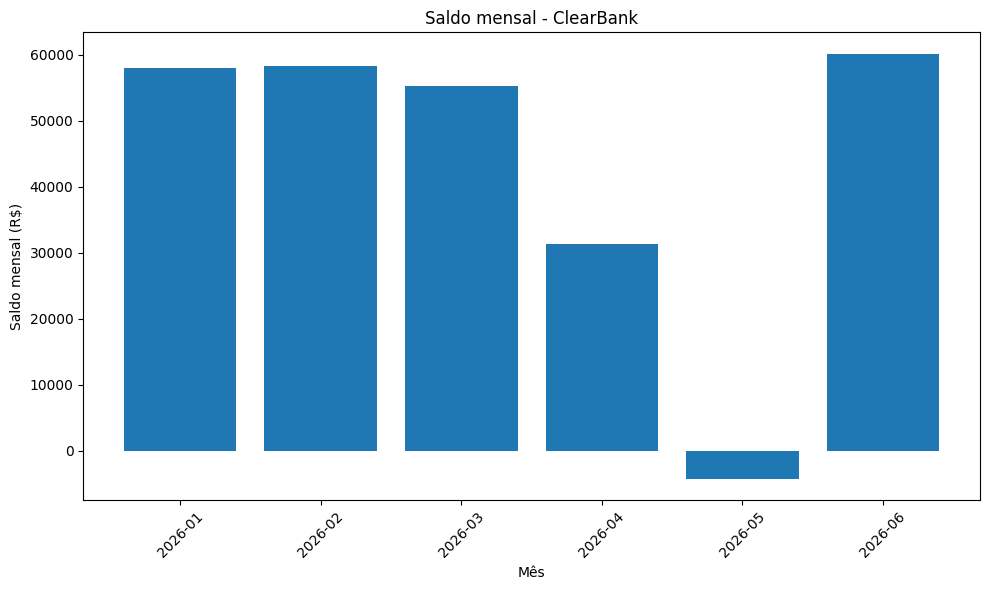

In [20]:
plt.figure(figsize=(10, 6))

plt.bar(resumo_pandas["mes"], resumo_pandas["saldo"], label="Saldo")

plt.title("Saldo mensal - ClearBank")
plt.xlabel("Mês")
plt.ylabel("Saldo mensal (R$)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("grafico.png", dpi=300)

plt.show()